# Exploratory Data Analysis - Crop Disease Dataset
## Analyzing PlantVillage Dataset for Disease Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset Metadata

In [2]:
df = pd.read_csv('../data/processed/dataset_metadata.csv')
print(f"Total images: {len(df):,}")
df.head()

Total images: 20,638


,image_path,class_label,crop,disease,is_healthy,width,height,file_size_kb
0,c:\Users\Administrator\Desktop\pacifique\AGRIC...,Pepper__bell___Bacterial_spot,Pepper__bell,Bacterial_spot,False,256,256,17.628906
1,c:\Users\Administrator\Desktop\pacifique\AGRIC...,Pepper__bell___Bacterial_spot,Pepper__bell,Bacterial_spot,False,256,256,20.713867
2,c:\Users\Administrator\Desktop\pacifique\AGRIC...,Pepper__bell___Bacterial_spot,Pepper__bell,Bacterial_spot,False,256,256,18.119141
3,c:\Users\Administrator\Desktop\pacifique\AGRIC...,Pepper__bell___Bacterial_spot,Pepper__bell,Bacterial_spot,False,256,256,25.875000
4,c:\Users\Administrator\Desktop\pacifique\AGRIC...,Pepper__bell___Bacterial_spot,Pepper__bell,Bacterial_spot,False,256,256,19.059570


## 2. Dataset Overview

In [3]:
print("Dataset Statistics:")
print(f"Total Images: {len(df):,}")
print(f"Number of Classes: {df['class_label'].nunique()}")
print(f"Number of Crops: {df['crop'].nunique()}")
print(f"Number of Diseases: {df['disease'].nunique()}")
print(f"Healthy Samples: {df['is_healthy'].sum():,}")
print(f"Diseased Samples: {(~df['is_healthy']).sum():,}")

Dataset Statistics:
Total Images: 20,638
Number of Classes: 15
Number of Crops: 3
Number of Diseases: 10
Healthy Samples: 3,221
Diseased Samples: 17,417


## 3. Class Distribution

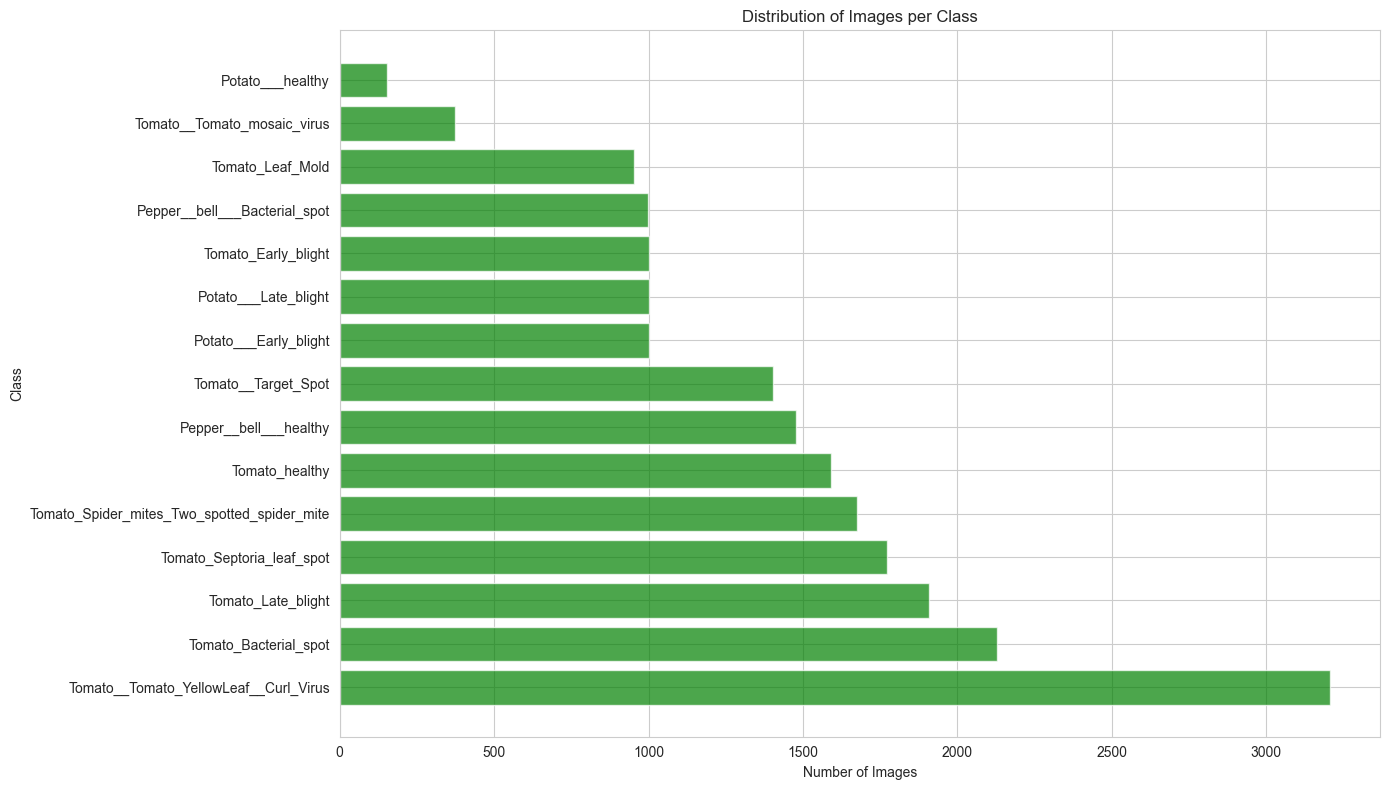


Most common class: Tomato__Tomato_YellowLeaf__Curl_Virus (3,208 images)
Least common class: Potato___healthy (152 images)


In [4]:
plt.figure(figsize=(14, 8))
class_counts = df['class_label'].value_counts()
plt.barh(class_counts.index, class_counts.values, color='green', alpha=0.7)
plt.xlabel('Number of Images')
plt.ylabel('Class')
plt.title('Distribution of Images per Class')
plt.tight_layout()
plt.show()

print(f"\nMost common class: {class_counts.index[0]} ({class_counts.values[0]:,} images)")
print(f"Least common class: {class_counts.index[-1]} ({class_counts.values[-1]:,} images)")

## 4. Crop Distribution

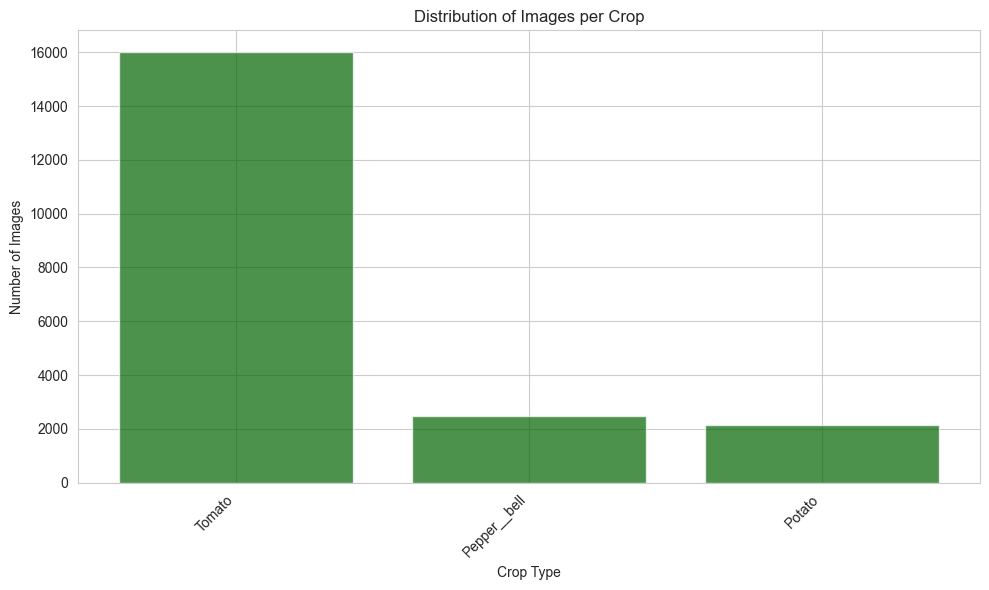

In [5]:
plt.figure(figsize=(10, 6))
crop_counts = df['crop'].value_counts()
plt.bar(crop_counts.index, crop_counts.values, color='darkgreen', alpha=0.7)
plt.xlabel('Crop Type')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Crop')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Healthy vs Diseased

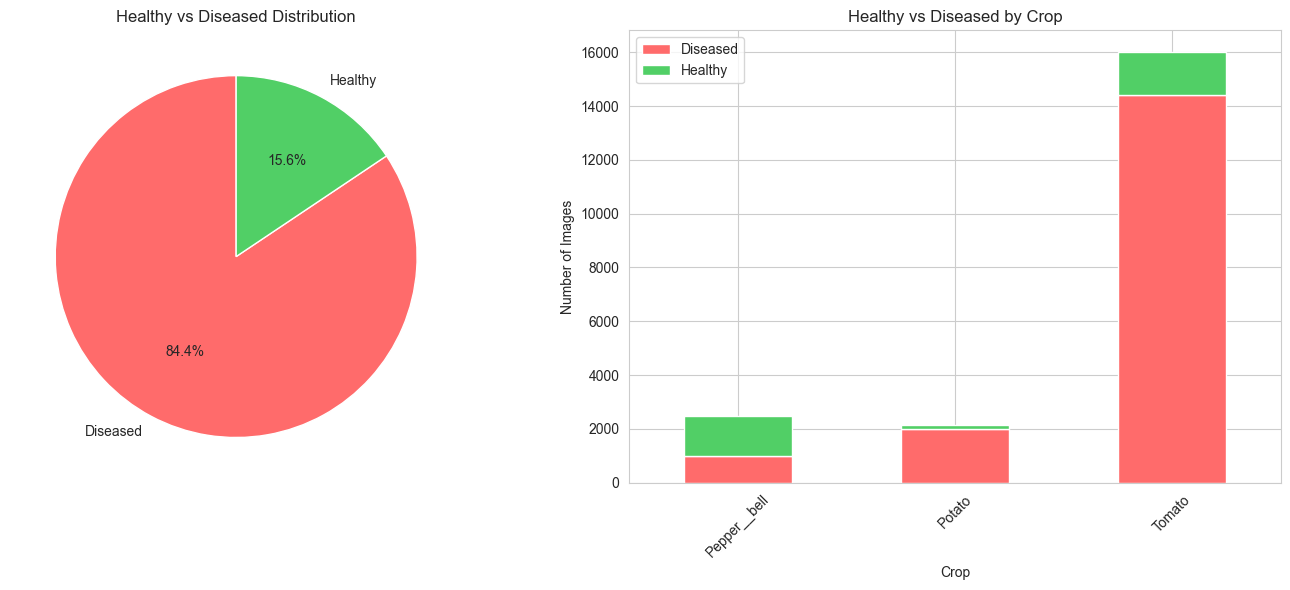

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

health_counts = df['is_healthy'].value_counts()
ax1.pie(health_counts.values, labels=['Diseased', 'Healthy'], autopct='%1.1f%%', 
        colors=['#ff6b6b', '#51cf66'], startangle=90)
ax1.set_title('Healthy vs Diseased Distribution')

crop_health = df.groupby(['crop', 'is_healthy']).size().unstack(fill_value=0)
crop_health.plot(kind='bar', stacked=True, ax=ax2, color=['#ff6b6b', '#51cf66'])
ax2.set_xlabel('Crop')
ax2.set_ylabel('Number of Images')
ax2.set_title('Healthy vs Diseased by Crop')
ax2.legend(['Diseased', 'Healthy'])
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Image Properties Analysis

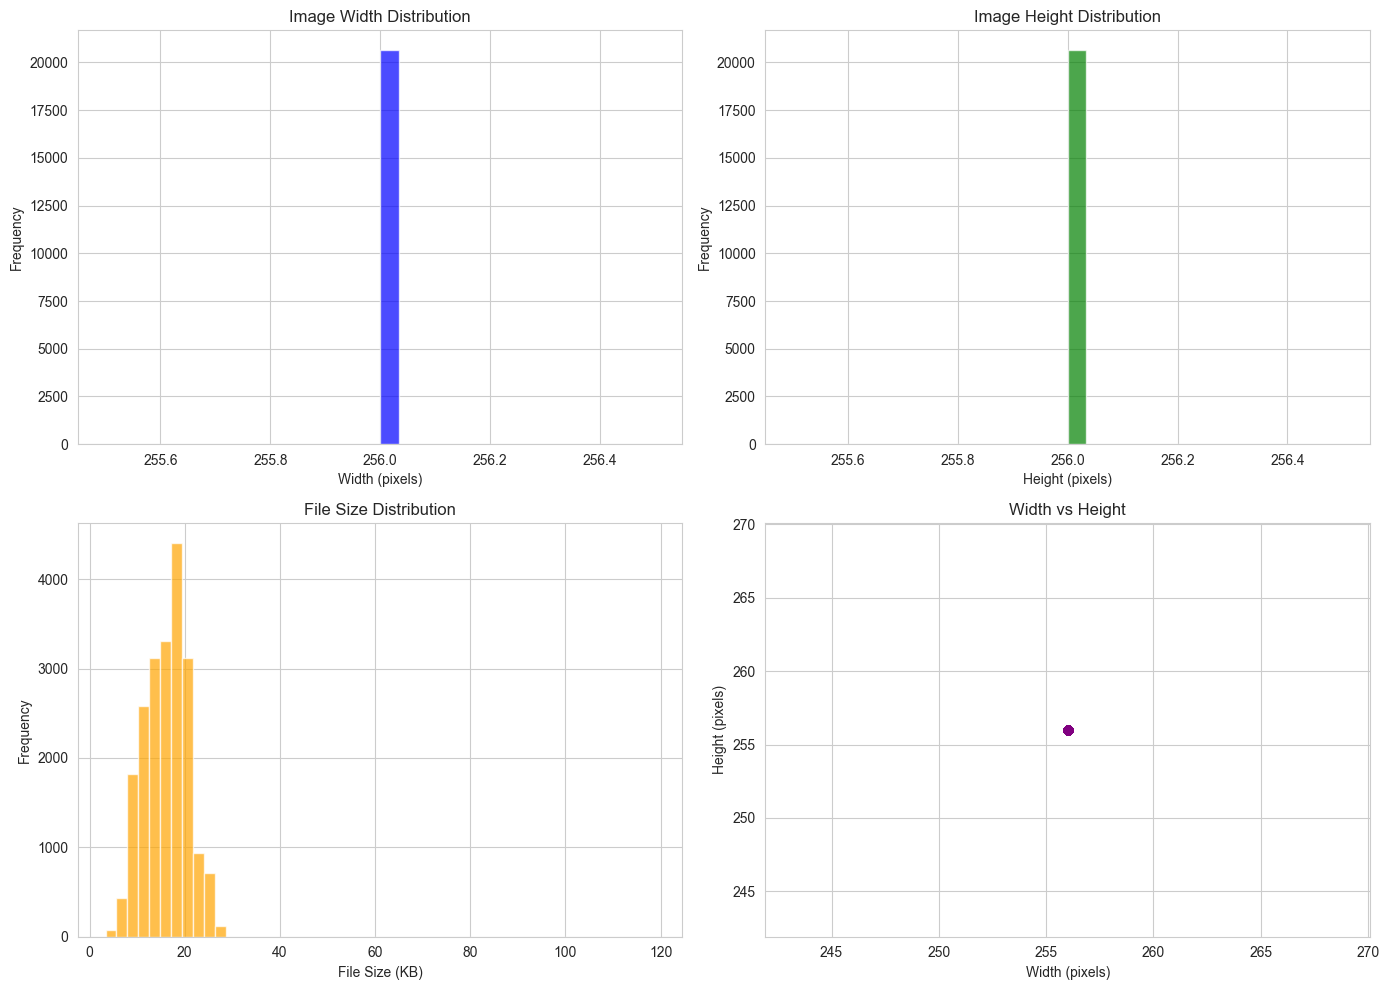


Image Statistics:
Average Width: 256 pixels
Average Height: 256 pixels
Average File Size: 16.19 KB


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['width'], bins=30, color='blue', alpha=0.7)
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Image Width Distribution')

axes[0, 1].hist(df['height'], bins=30, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Image Height Distribution')

axes[1, 0].hist(df['file_size_kb'], bins=50, color='orange', alpha=0.7)
axes[1, 0].set_xlabel('File Size (KB)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('File Size Distribution')

axes[1, 1].scatter(df['width'], df['height'], alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Width (pixels)')
axes[1, 1].set_ylabel('Height (pixels)')
axes[1, 1].set_title('Width vs Height')

plt.tight_layout()
plt.show()

print(f"\nImage Statistics:")
print(f"Average Width: {df['width'].mean():.0f} pixels")
print(f"Average Height: {df['height'].mean():.0f} pixels")
print(f"Average File Size: {df['file_size_kb'].mean():.2f} KB")

## 7. Disease Distribution

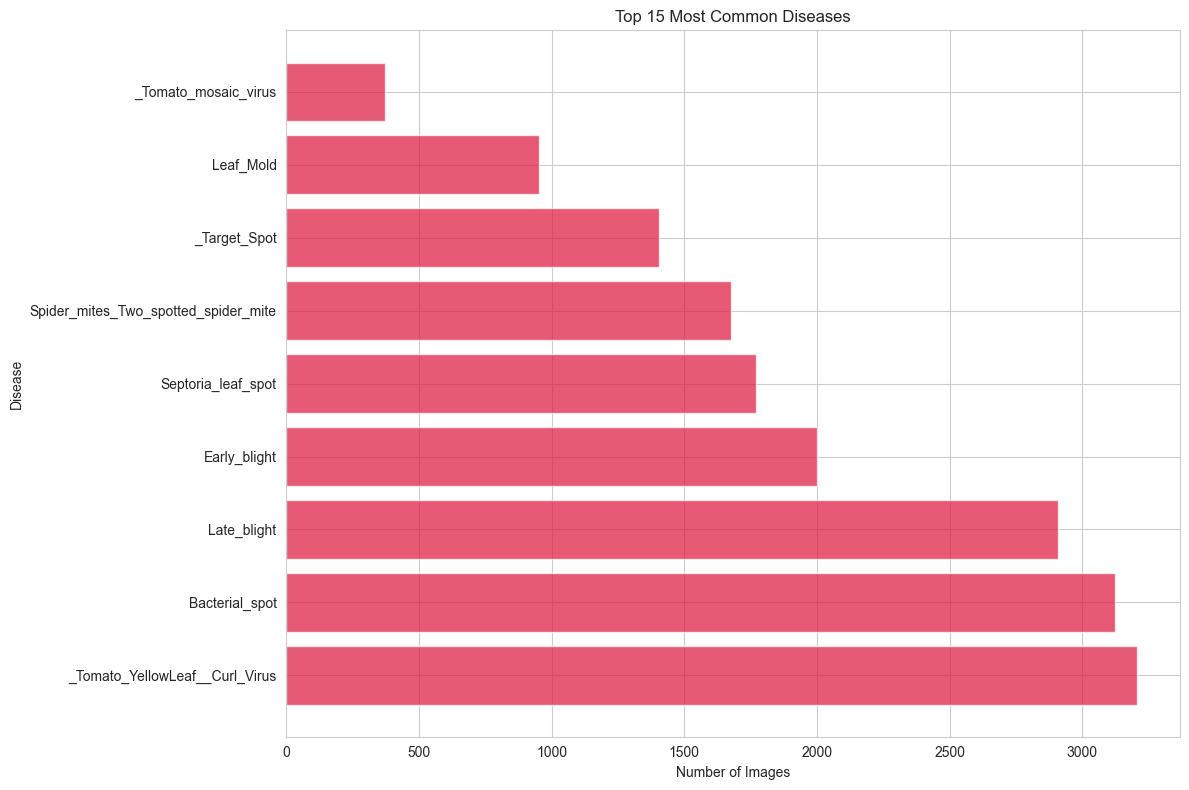

In [10]:
diseased_df = df[df['is_healthy'] == False]
disease_counts = diseased_df['disease'].value_counts().head(15)

plt.figure(figsize=(12, 8))
plt.barh(disease_counts.index, disease_counts.values, color='crimson', alpha=0.7)
plt.xlabel('Number of Images')
plt.ylabel('Disease')
plt.title('Top 15 Most Common Diseases')
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [11]:
print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total Images: {len(df):,}")
print(f"Total Classes: {df['class_label'].nunique()}")
print(f"Total Crops: {df['crop'].nunique()}")
print(f"Total Diseases: {df['disease'].nunique()}")
print(f"\nHealthy Images: {df['is_healthy'].sum():,} ({df['is_healthy'].sum()/len(df)*100:.1f}%)")
print(f"Diseased Images: {(~df['is_healthy']).sum():,} ({(~df['is_healthy']).sum()/len(df)*100:.1f}%)")
print(f"\nAverage Image Size: {df['file_size_kb'].mean():.2f} KB")
print(f"Total Dataset Size: {df['file_size_kb'].sum()/1024:.2f} MB")
print(f"\nMost Common Dimension: {df['width'].mode()[0]}x{df['height'].mode()[0]} pixels")
print("="*60)


DATASET SUMMARY
Total Images: 20,638
Total Classes: 15
Total Crops: 3
Total Diseases: 10

Healthy Images: 3,221 (15.6%)
Diseased Images: 17,417 (84.4%)

Average Image Size: 16.19 KB
Total Dataset Size: 326.38 MB

Most Common Dimension: 256x256 pixels
